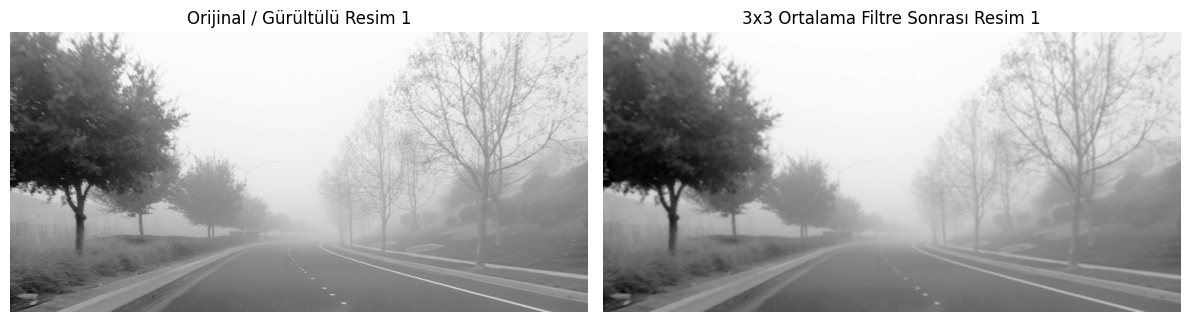

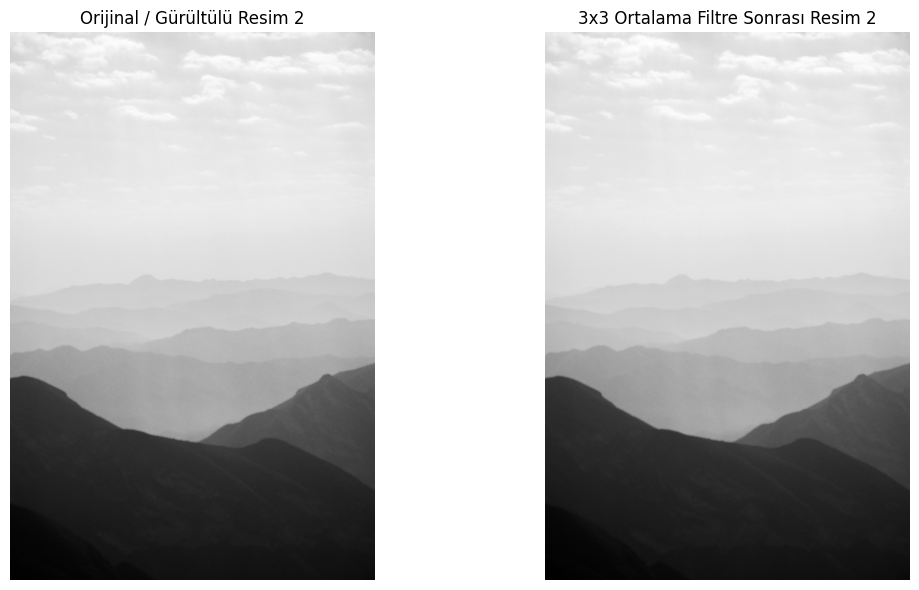

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def manual_convolution_2d(image, kernel):
    # Görüntü ve kernel boyutlarını alalım
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Çekirdek merkezinden kenarlara olan uzaklıklar
    pad_h = kernel_height // 2
    pad_w = kernel_width // 2

    # Çıktı görüntüsünü oluşturup kenarları sıfırlarla dolduralım (padding)
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output_img = np.zeros_like(image, dtype=np.float32)

    # Konvolüsyon işlemini el ile gerçekleştirelim
    for y in range(img_height):
        for x in range(img_width):
            # Mevcut pikselin çevresindeki pencereyi alalım
            window = padded_img[y:y + kernel_height, x:x + kernel_width]
            # Eleman elemana çarpıp toplayalım (Konvolüsyon)
            output_img[y, x] = np.sum(window * kernel)

    return np.clip(output_img, 0, 255).astype(np.uint8)

# 3x3 Ortalama (Mean) filtresi çekirdeği (Bütün elemanların ortalamasını alır)
mean_kernel_3x3 = np.ones((3, 3), dtype=np.float32) / 9.0

# Resimleri işle
paths = ['/content/resim1.jpeg', '/content/resim 2.jpeg']

for i, path in enumerate(paths, start=1):
    # Görüntüyü gri tonlamalı oku
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Hata: {path} yüklenemedi!")
        continue

    # Gürültü bastırma işlemini gerçekleştir
    filtered_img = manual_convolution_2d(img, mean_kernel_3x3)

    # Sonuçları görselleştir
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Orijinal / Gürültülü Resim {i}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(f'3x3 Ortalama Filtre Sonrası Resim {i}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()